# Hybrid Directional Signal Model — AMD / NVDA

**Key insight from v1:** The model's signal lives in *direction*, not magnitude.

**What changed in v2:**
- ✅ Pivoted to binary direction classification (Up/Down)
- ✅ Uses Logistic Regression instead of manual formula
- ✅ Proper Train → Validation → Test split (60/20/20)
- ✅ Optuna tunes on **validation only** — test set is never touched until final eval
- ✅ No data leakage — features shifted correctly
- ✅ Comparison vs naive baseline on unseen test set

In [1]:
# ── Installs ──────────────────────────────────────────────────────────────────
# Uncomment if needed:
# !pip install yfinance scikit-learn optuna pandas numpy matplotlib

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress trial spam

import yfinance as yf
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

print("All imports OK")

All imports OK


## 1. Data Download

In [2]:
TICKER = "NVDA"   # ← change to "AMD" if needed

raw = yf.download(TICKER, start="2018-01-01", end="2025-01-01", progress=False)

# Flatten multi-index if yfinance returns one
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

data = raw[['Close']].dropna().copy()
print(f"Downloaded {len(data)} rows for {TICKER}")
print(data.tail(3))

Downloaded 1761 rows for NVDA
Price            Close
Date                  
2024-12-27  136.965118
2024-12-30  137.444962
2024-12-31  134.246017


## 2. Feature Engineering

Three interpretable features — same as v1, but now they feed a *classifier*:

| Feature | Formula | Captures |
|---------|---------|----------|
| `MA_residual` | Close − MA(window) | Mean-reversion signal |
| `Momentum` | Close − Close.shift(k) | Trend acceleration |
| `MA_slope` | MA(t) − MA(t-1) | Trend direction |

**Leakage guard:** All features are shifted by 1 before being used as predictors, so we only use information available at prediction time (yesterday's values → predict today's direction).

In [3]:
def build_features(df: pd.DataFrame, ma_window: int, momentum_window: int) -> pd.DataFrame:
    """
    Build the three features and the binary target.
    All feature columns are lagged by 1 day to prevent lookahead bias.
    """
    out = df[['Close']].copy()

    # ── Raw features (computed on current day) ──────────────────────────────
    ma = out['Close'].rolling(ma_window).mean()
    out['f_residual']  = out['Close'] - ma                          # mean-reversion
    out['f_momentum']  = out['Close'] - out['Close'].shift(momentum_window)  # momentum
    out['f_ma_slope']  = ma - ma.shift(1)                           # trend slope

    # ── Target: will tomorrow's close be HIGHER than today's? ───────────────
    out['target'] = (out['Close'].shift(-1) > out['Close']).astype(int)

    # ── Lag features by 1 day (use yesterday's info to predict today) ────────
    for col in ['f_residual', 'f_momentum', 'f_ma_slope']:
        out[col] = out[col].shift(1)

    out.dropna(inplace=True)
    return out


FEATURE_COLS = ['f_residual', 'f_momentum', 'f_ma_slope']

# Quick preview with default params
preview = build_features(data, ma_window=20, momentum_window=5)
print(preview[FEATURE_COLS + ['target']].tail(5))
print(f"\nClass balance: {preview['target'].value_counts(normalize=True).to_dict()}")

Price       f_residual  f_momentum  f_ma_slope  target
Date                                                  
2024-12-24    2.712957    7.667496   -0.113474       0
2024-12-26    3.052393    9.826797    0.210400       0
2024-12-27    2.611553   11.016388    0.150922       1
2024-12-30   -0.391438    6.327957    0.083939       0
2024-12-31    0.125917    2.789093   -0.037512       0

Class balance: {1: 0.5385057471264367, 0: 0.4614942528735632}


## 3. Train / Validation / Test Split

```
─────────────────────────────────────────────────────
 TRAIN (60%)  │  VALIDATION (20%)  │  TEST (20%)
─────────────────────────────────────────────────────
              ↑ Optuna tunes here  ↑ Final evaluation only
```

The **test set is never touched** until the very last cell.

In [4]:
def time_split(df: pd.DataFrame):
    n = len(df)
    i_train = int(0.6 * n)
    i_val   = int(0.8 * n)
    return df.iloc[:i_train], df.iloc[i_train:i_val], df.iloc[i_val:]


# We'll do the full split inside the Optuna objective.
# Here just confirm sizes with default params.
df_preview = build_features(data, ma_window=20, momentum_window=5)
train_p, val_p, test_p = time_split(df_preview)
print(f"Train rows : {len(train_p)}")
print(f"Val rows   : {len(val_p)}")
print(f"Test rows  : {len(test_p)}")

Train rows : 1044
Val rows   : 348
Test rows  : 348


## 4. Naive Baseline

The naive baseline predicts "Up" every day (or majority class). We compute its accuracy on the **test set** — this is the bar our model must beat.

In [5]:
# Majority-class naive on test set (using default params preview)
majority_class = int(train_p['target'].mode()[0])
naive_preds    = np.full(len(test_p), majority_class)
naive_acc      = accuracy_score(test_p['target'], naive_preds)

print(f"Naive majority-class accuracy on test set : {naive_acc:.2%}")
print(f"(Majority class = {majority_class}, meaning price goes {'UP' if majority_class == 1 else 'DOWN'} more often)")

Naive majority-class accuracy on test set : 55.75%
(Majority class = 1, meaning price goes UP more often)


## 5. Hyperparameter Optimisation with Optuna

Optuna tunes:
- `ma_window` — how many days for the moving average
- `momentum_window` — lookback for momentum calculation
- `C` — logistic regression regularisation strength

Objective: **maximise directional accuracy on the validation set only.**

In [6]:
def objective(trial):
    ma_window       = trial.suggest_int("ma_window", 5, 50)
    momentum_window = trial.suggest_int("momentum_window", 3, 20)
    C               = trial.suggest_float("C", 1e-3, 10.0, log=True)

    df = build_features(data, ma_window=ma_window, momentum_window=momentum_window)
    train, val, _ = time_split(df)   # test is NEVER used here

    X_train, y_train = train[FEATURE_COLS].values, train['target'].values
    X_val,   y_val   = val[FEATURE_COLS].values,   val['target'].values

    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_val_s   = scaler.transform(X_val)

    clf = LogisticRegression(C=C, max_iter=500, random_state=42)
    clf.fit(X_train_s, y_train)

    val_acc = accuracy_score(y_val, clf.predict(X_val_s))
    return val_acc


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100, show_progress_bar=True)

best = study.best_params
print(f"\nBest hyperparameters : {best}")
print(f"Best validation accuracy : {study.best_value:.2%}")

  0%|          | 0/100 [00:00<?, ?it/s]


Best hyperparameters : {'ma_window': 21, 'momentum_window': 7, 'C': 0.3639454033376914}
Best validation accuracy : 56.90%


## 6. Final Model — Train on Train+Val, Evaluate on Test

Now that hyperparameters are fixed, we re-train on **train + validation** and evaluate once on the held-out test set.

In [7]:
# Build dataset with best params
df_final = build_features(
    data,
    ma_window       = best['ma_window'],
    momentum_window = best['momentum_window']
)

train_f, val_f, test_f = time_split(df_final)

# Combine train + val for final fit
train_val_f = pd.concat([train_f, val_f])

X_trainval = train_val_f[FEATURE_COLS].values
y_trainval = train_val_f['target'].values
X_test     = test_f[FEATURE_COLS].values
y_test     = test_f['target'].values

scaler_final = StandardScaler().fit(X_trainval)
X_trainval_s = scaler_final.transform(X_trainval)
X_test_s     = scaler_final.transform(X_test)

model_final = LogisticRegression(C=best['C'], max_iter=500, random_state=42)
model_final.fit(X_trainval_s, y_trainval)

y_pred  = model_final.predict(X_test_s)
test_acc = accuracy_score(y_test, y_pred)

# Naive baseline on same test set
majority_final = int(y_trainval.mean() >= 0.5)
naive_pred_final = np.full(len(y_test), majority_final)
naive_acc_final  = accuracy_score(y_test, naive_pred_final)

print("═" * 45)
print(f"  Naive baseline accuracy  : {naive_acc_final:.2%}")
print(f"  Model test accuracy      : {test_acc:.2%}")
print(f"  Improvement over naive   : {(test_acc - naive_acc_final):+.2%}")
print("═" * 45)
print()
print(classification_report(y_test, y_pred, target_names=['Down', 'Up']))

═════════════════════════════════════════════
  Naive baseline accuracy  : 55.75%
  Model test accuracy      : 51.44%
  Improvement over naive   : -4.31%
═════════════════════════════════════════════

              precision    recall  f1-score   support

        Down       0.45      0.45      0.45       154
          Up       0.56      0.57      0.57       194

    accuracy                           0.51       348
   macro avg       0.51      0.51      0.51       348
weighted avg       0.51      0.51      0.51       348



## 7. Visualisations

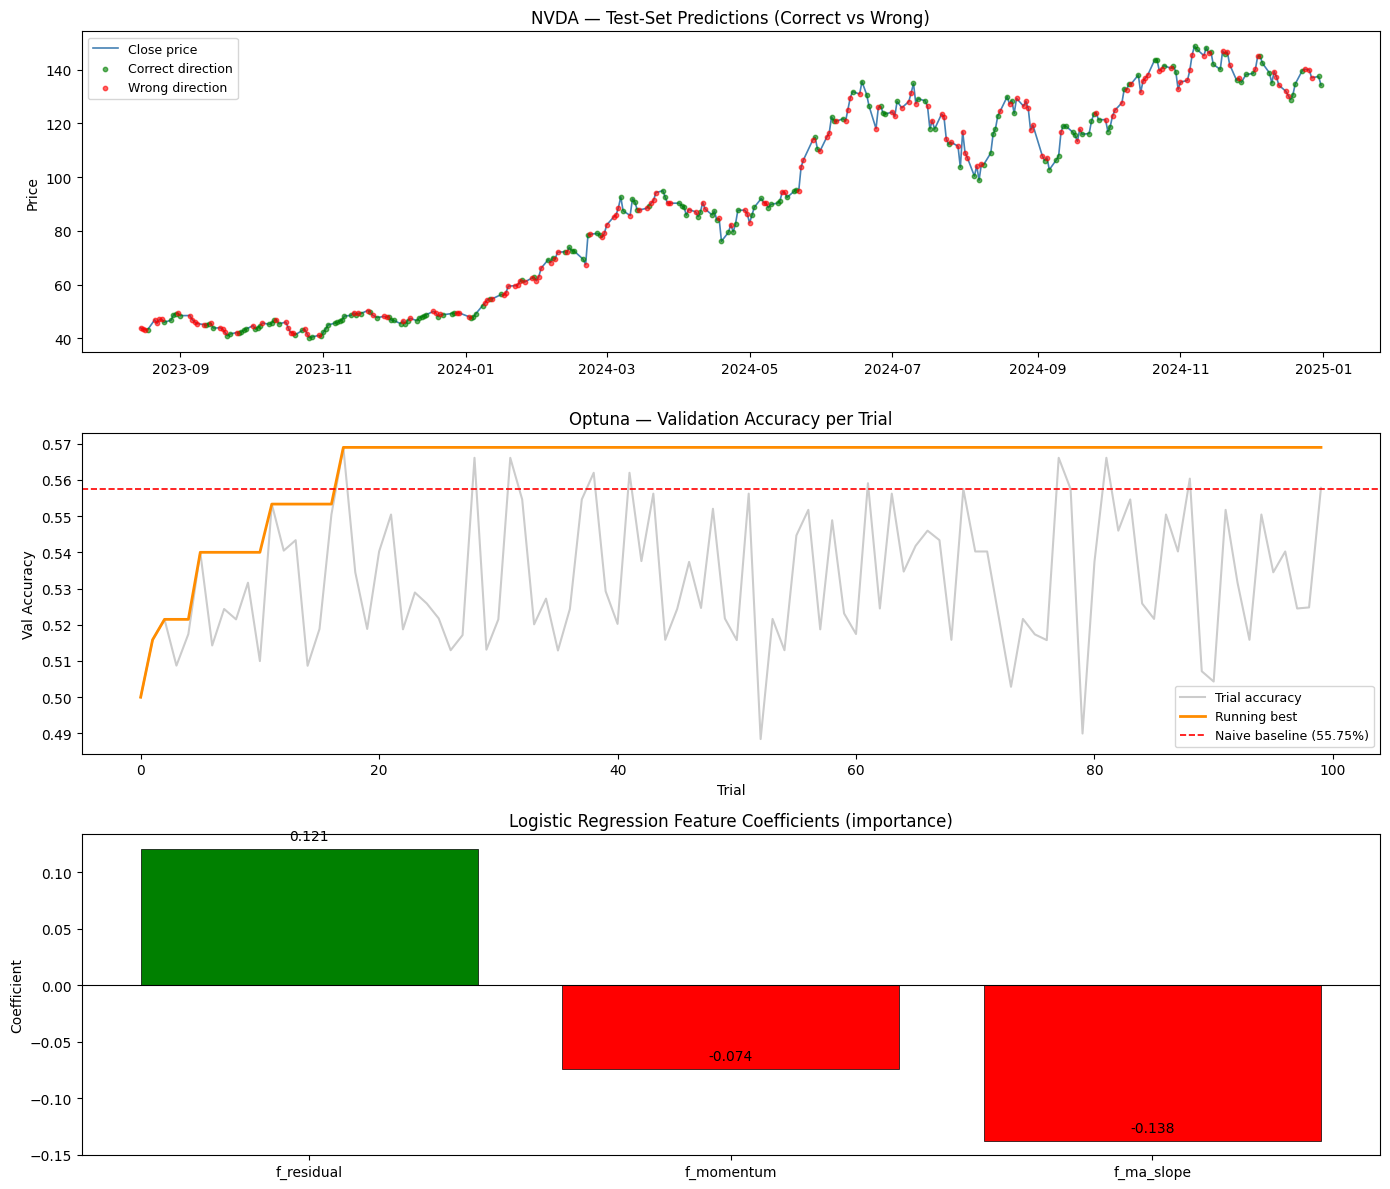

Figure saved to results.png


In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# ── Plot 1: Price + correct / wrong predictions ──────────────────────────────
ax = axes[0]
test_prices = test_f['Close']
correct = y_pred == y_test

ax.plot(test_prices.index, test_prices.values, color='steelblue', lw=1.2, label='Close price')
ax.scatter(test_prices.index[correct],  test_prices.values[correct],
           c='green', s=10, alpha=0.6, label='Correct direction', zorder=3)
ax.scatter(test_prices.index[~correct], test_prices.values[~correct],
           c='red',   s=10, alpha=0.6, label='Wrong direction',   zorder=3)
ax.set_title(f"{TICKER} — Test-Set Predictions (Correct vs Wrong)")
ax.legend(fontsize=9)
ax.set_ylabel("Price")

# ── Plot 2: Optuna optimisation history ───────────────────────────────────────
ax2 = axes[1]
trial_values = [t.value for t in study.trials]
running_best = pd.Series(trial_values).cummax()
ax2.plot(trial_values, alpha=0.4, color='gray', label='Trial accuracy')
ax2.plot(running_best, color='darkorange', lw=2, label='Running best')
ax2.axhline(naive_acc_final, color='red', ls='--', lw=1.2, label=f'Naive baseline ({naive_acc_final:.2%})')
ax2.set_title("Optuna — Validation Accuracy per Trial")
ax2.set_xlabel("Trial")
ax2.set_ylabel("Val Accuracy")
ax2.legend(fontsize=9)

# ── Plot 3: Feature importances (logistic regression coefficients) ────────────
ax3 = axes[2]
coefs = model_final.coef_[0]
colors = ['green' if c > 0 else 'red' for c in coefs]
bars = ax3.bar(FEATURE_COLS, coefs, color=colors, edgecolor='black', linewidth=0.5)
ax3.axhline(0, color='black', lw=0.8)
ax3.set_title("Logistic Regression Feature Coefficients (importance)")
ax3.set_ylabel("Coefficient")
for bar, val in zip(bars, coefs):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{val:.3f}", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig("results.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to results.png")

## 8. Summary & Next Steps

### What this model is
A **directional signal model** — predicts Up/Down for the next trading day using three interpretable features derived from price history.

### What good results look like
| Metric | Target |
|--------|--------|
| Test directional accuracy | 55–58% |
| Consistency across splits | Stable |
| vs naive baseline | Clearly better |

### Recommended next steps
1. **Add volatility feature** — e.g. rolling std of returns → captures regime shifts
2. **Walk-forward validation** — more rigorous than a single split; mimics live trading
3. **Try XGBoost** — drop-in replacement for LogisticRegression, often stronger on tabular data
4. **Backtest returns** — convert directional signal into P&L, compute Sharpe ratio
5. **Run on AMD** — change `TICKER = "AMD"` at the top and re-run everything